
**Experiment 1: Working with Python packages-Numpy, Scipy, Scikit-Learn,
Matplotlib**

**1. Loan Amount Prediction**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


#Loading data set
df = pd.read_csv(r"/content/drive/MyDrive/loan_approval_dataset.csv")
print(df.head())

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [ ]:
#Exploratory data analytics

#summary statistics
print("\nInfo\n")
print(df.info())
print("\nColumns\n")
print(df.columns)
print("\nShape\n")
print(df.shape)
print("\nDescription\n")
print(df.describe())


Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None

Co

In [ ]:
print(df.columns)

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

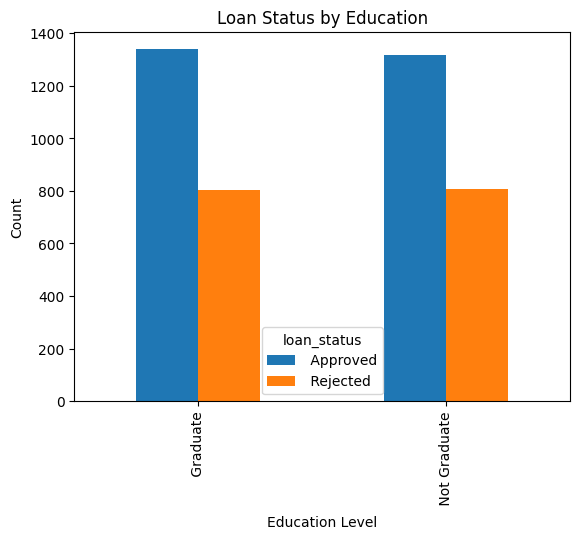

<Figure size 640x480 with 0 Axes>

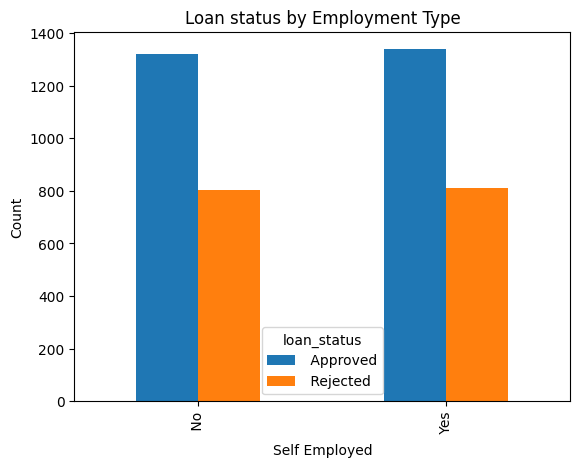

In [ ]:
#visualization
#1.Grouped Bars
#Strip spaces
df.columns = df.columns.str.strip()
plt.figure()
pd.crosstab(df['education'],df['loan_status']).plot(kind="bar")
plt.title("Loan Status by Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

plt.figure()
pd.crosstab(df['self_employed'],df['loan_status']).plot(kind="bar")
plt.title("Loan status by Employment Type")
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.show()


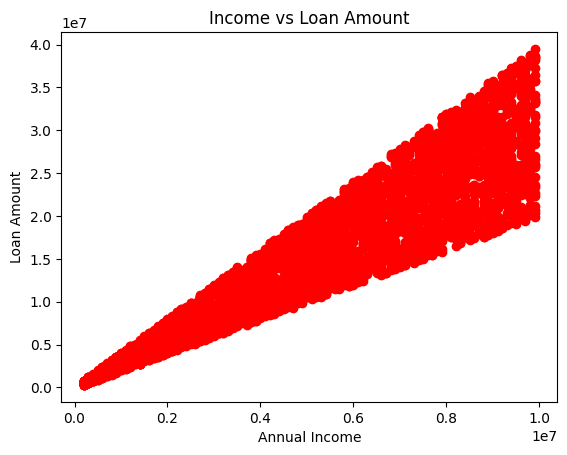

In [ ]:
#2.Scatter Plot
plt.figure()
plt.scatter(df['income_annum'],df['loan_amount'],c="red")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

In [ ]:
#Data Preprocessing
#Checking for null values
df.isnull().sum()

#Drop unnecessary columns
df = df.drop(columns=['loan_id'])
print(df)

      no_of_dependents      education self_employed  income_annum  \
0                    2       Graduate            No       9600000   
1                    0   Not Graduate           Yes       4100000   
2                    3       Graduate            No       9100000   
3                    3       Graduate            No       8200000   
4                    5   Not Graduate           Yes       9800000   
...                ...            ...           ...           ...   
4264                 5       Graduate           Yes       1000000   
4265                 0   Not Graduate           Yes       3300000   
4266                 2   Not Graduate            No       6500000   
4267                 1   Not Graduate            No       4100000   
4268                 1       Graduate            No       9200000   

      loan_amount  loan_term  cibil_score  residential_assets_value  \
0        29900000         12          778                   2400000   
1        12200000          8 

In [ ]:
asset_cols = [
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]
for cols in asset_cols:
    print((df[cols] < 0).sum())

df[asset_cols] = df[asset_cols].clip(lower=0)
df[asset_cols]

28
0
0
0


,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2400000,17600000,22700000,8000000
1,2700000,2200000,8800000,3300000
2,7100000,4500000,33300000,12800000
3,18200000,3300000,23300000,7900000
4,12400000,8200000,29400000,5000000
...,...,...,...,...
4264,2800000,500000,3300000,800000
4265,4200000,2900000,11000000,1900000
4266,1200000,12400000,18100000,7300000
4267,8200000,700000,14100000,5800000


In [ ]:
df['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [ ]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
#Irrelevant features - None
#Encode target
df['loan_status'] = df['loan_status'].astype(str).str.strip().str.title()
df['loan_status'] = df['loan_status'].map({"Approved":1,"Rejected":0})

#Encode categorical predictors
df = pd.get_dummies(df,columns=["education","self_employed"],drop_first=True)

#Separating features & target
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())


Features:
   no_of_dependents  income_annum  loan_amount  loan_term  cibil_score  \
0                 2       9600000     29900000         12          778   
1                 0       4100000     12200000          8          417   
2                 3       9100000     29700000         20          506   
3                 3       8200000     30700000          8          467   
4                 5       9800000     24200000         20          382   

   residential_assets_value  commercial_assets_value  luxury_assets_value  \
0                   2400000                 17600000             22700000   
1                   2700000                  2200000              8800000   
2                   7100000                  4500000             33300000   
3                  18200000                  3300000             23300000   
4                  12400000                  8200000             29400000   

   bank_asset_value  education_ Not Graduate  self_employed_ Yes  
0           800

In [ ]:
#Normalize / Standardize Numerics
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Feature Matrix Shape:",X_scaled.shape)


Scaled Feature Matrix Shape: (4269, 11)


In [ ]:
#Feature Selection
from sklearn.feature_selection import SelectKBest,chi2,f_classif
#1.Chi-Square
chi2_selector = SelectKBest(score_func = chi2,k=5)
X_chi2 = chi2_selector.fit_transform(X,y)
print("\nChi-square Selected Features Shape:",X_chi2.shape)

chi2_scores = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi2_selector.scores_
}).sort_values(by="Chi2 Score", ascending=False)

print("\nChi-Square Scores:")
print(chi2_scores)



Chi-square Selected Features Shape: (4269, 5)

Chi-Square Scores:
                     Feature    Chi2 Score
2                loan_amount  6.015537e+06
7        luxury_assets_value  5.592631e+06
5   residential_assets_value  4.993060e+06
1               income_annum  1.533387e+06
6    commercial_assets_value  1.124060e+06
8           bank_asset_value  4.162549e+05
4                cibil_score  1.255779e+05
3                  loan_term  1.630650e+02
0           no_of_dependents  1.611992e+00
9    education_ Not Graduate  5.185351e-02
10        self_employed_ Yes  2.514945e-04


In [ ]:
#ANOVA F-Test
anova_selector = SelectKBest(score_func=f_classif, k=5)
X_anova = anova_selector.fit_transform(X_scaled, y)

print("\nANOVA Selected Features Shape:", X_anova.shape)

anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA F-Score": anova_selector.scores_
}).sort_values(by="ANOVA F-Score", ascending=False)

print("\nANOVA Scores:")
print(anova_scores)


ANOVA Selected Features Shape: (4269, 5)

ANOVA Scores:
                     Feature  ANOVA F-Score
4                cibil_score    6235.054591
3                  loan_term      55.225458
0           no_of_dependents       1.400600
2                loan_amount       1.113176
7        luxury_assets_value       1.020728
1               income_annum       0.984669
5   residential_assets_value       0.882378
6    commercial_assets_value       0.290152
8           bank_asset_value       0.196066
9    education_ Not Graduate       0.103202
10        self_employed_ Yes       0.000506


In [ ]:
selected_features = X.columns[anova_selector.get_support()]
print("Selected Features:",list(selected_features))

Selected Features: ['no_of_dependents', 'loan_amount', 'loan_term', 'cibil_score', 'luxury_assets_value']


In [ ]:
#Data Splitting
from sklearn.model_selection import train_test_split
#Split it into training and test
X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

#Validation and Test
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Training set:",X_train.shape,y_train.shape)
print("Validation set:",X_val.shape,y_val.shape)
print("Testing set:",X_test.shape,y_test.shape)


Training set: (2988, 11) (2988,)
Validation set: (640, 11) (640,)
Testing set: (641, 11) (641,)


In [ ]:
#Performance Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,fbeta_score,confusion_matrix

print(y.value_counts()) #DS not balanced
model = LogisticRegression(max_iter = 200)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

#precision
precision = precision_score(y_test,y_pred)
#Recall
recall = recall_score(y_test,y_pred)
#F1-score
f05 = fbeta_score(y_test,y_pred,beta = 0.5) #since Precision is more imp
print("Precision:", precision)
print("Recall   :", recall)
print("F0.5 Score :", f05)


loan_status
1    2656
0    1613
Name: count, dtype: int64
Precision: 0.9356435643564357
Recall   : 0.9473684210526315
F0.5 Score : 0.9379652605459057


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[216  26]
 [ 21 378]]


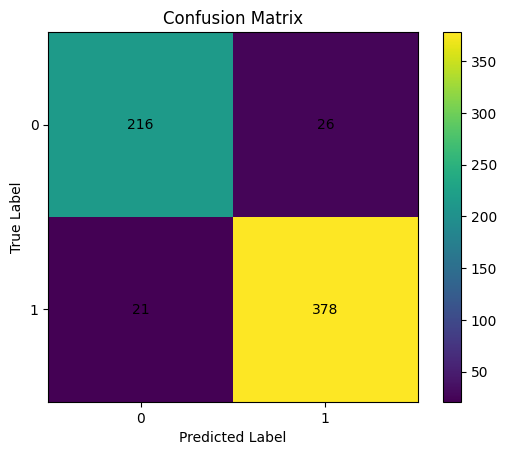

In [ ]:
#visualization

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

classes = np.unique(y_test)
plt.xticks(range(len(classes)),classes)
plt.yticks(range(len(classes)),classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha = "center",va="center")

plt.show()

**2. Handwriting Character Recognition**

In [7]:
#Loading data set
df = pd.read_csv(r"/content/drive/MyDrive/Handwriting/english.csv")
df.head()

,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [8]:
#Exploratory data analysis

#summary statistics
print("\nInfo\n")
print(df.info())
print("\nColumns\n")
print(df.columns)
print("\nShape\n")
print(df.shape)
print("\nDescription\n")
print(df.describe())


Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3410 non-null   object
 1   label   3410 non-null   object
dtypes: object(2)
memory usage: 53.4+ KB
None

Columns

Index(['image', 'label'], dtype='object')

Shape

(3410, 2)

Description

                     image label
count                 3410  3410
unique                3410    62
top     Img/img062-055.png     0
freq                     1    55


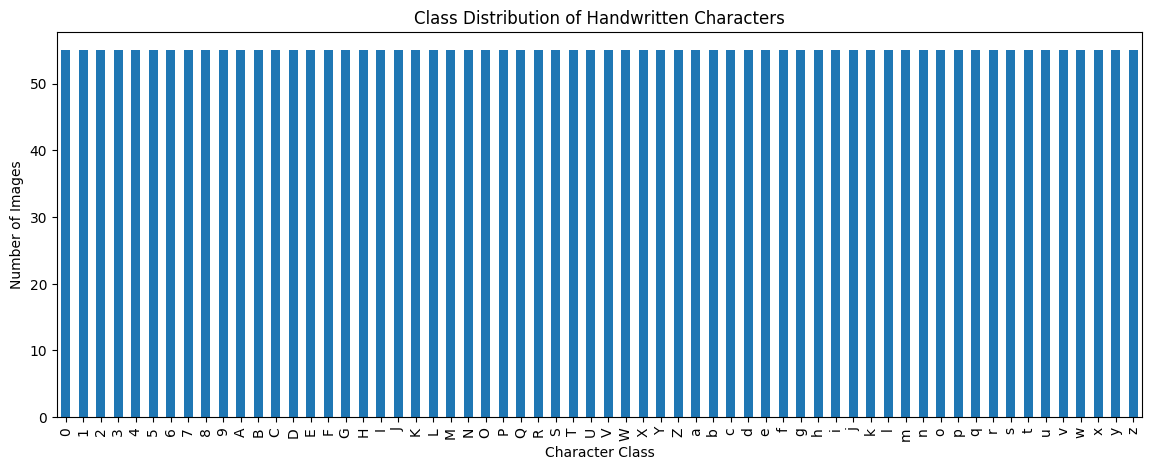

In [9]:
#visualisation
handwriting_df = pd.read_csv(r"/content/drive/MyDrive/Handwriting/english.csv")
y = handwriting_df['label']

label_counts = y.value_counts().sort_index()

plt.figure(figsize=(14,5))
label_counts.plot(kind='bar')
plt.title("Class Distribution of Handwritten Characters")
plt.xlabel("Character Class")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
import cv2
import numpy as np
import os # Import os module for path manipulation

IMG_SIZE = 28

def load_image(path):
    img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    if img is None:
        # It's good practice to log or handle cases where an image fails to load
        print(f"Warning: Could not load image from {path}. Skipping or handling as empty.")
        # Depending on desired behavior, could return np.zeros, raise error, etc.
        # For now, let's allow the error to propagate if it's still None after this check
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img / 255.0
    return img

# Prepend the base directory to the image paths
base_image_dir = r"/content/drive/MyDrive/Handwriting/" # Assuming this is where the 'Img' folder resides
full_image_paths = handwriting_df['image'].apply(lambda x: os.path.join(base_image_dir, x))

#separate features and target
X = np.array([load_image(p) for p in full_image_paths])
y = handwriting_df['label']

In [ ]:
#Encoding labels -> since obj->numerical characters
handwriting_df['label'] = handwriting_df['label'].astype('category').cat.codes
print(handwriting_df['label'].dtype)

#Flatten Images
X = X.reshape(X.shape[0],-1)
print(X.shape)

In [ ]:
#Data preprocessing

#Checking for missing values
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
X = X.reshape(X.shape[0], -1)
print(X.shape)

(3410, 784)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

anova = SelectKBest(f_classif, k='all')
X_anova = anova.fit_transform(X_scaled, y)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  46  49  50  51  52  53  54  55  56  57
  58  59  60  61  62  63  64  65  68  69  70  77  78  79  80  81  82  83
  84  85  86  87  88  89  90  91  92 100 105 106 107 108 109 110 111 112
 113 114 115 116 117 118 119 136 137 138 139 140 141 142 144 145 165 166
 167 168 169 170 193 194 195 196 197 198 221 222 223 224 225 226 250 251
 252 253 254 255 278 279 280 281 282 283 305 306 307 308 309 310 333 334
 335 336 337 338 361 362 363 364 365 366 367 390 391 392 393 394 395 418
 419 420 421 422 423 445 446 447 448 449 450 473 474 475 476 477 478 501
 502 503 504 505 506 529 530 531 532 533 534 535 536 557 558 559 560 561
 562 563 564 584 585 586 587 588 589 590 591 611 612 613 614 615 616 617
 618 6

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(confusion_matrix(y_test, y_pred))


F1 Score: 0.21946216771314628
[[2 0 2 ... 0 0 0]
 [0 3 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 1 0 ... 0 2 0]
 [0 0 0 ... 0 0 2]]


**3. Email Spam Detection**


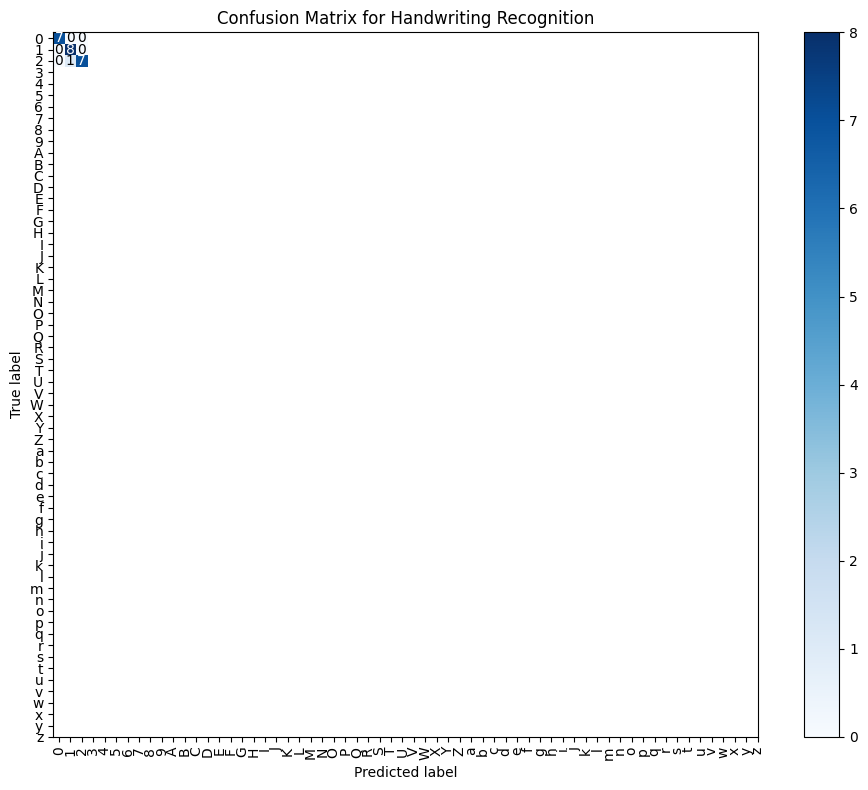

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Ensure 'cm' is available from previous execution for the handwriting task
# If cm is not defined, you might need to re-run the model prediction cell (mQPv1pAGpNqA) first.
# cm = confusion_matrix(y_test, y_pred) # Uncomment and run if cm is not defined

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Handwriting Recognition")
plt.colorbar()

# Get unique classes from y_test to label the axes
classes = np.unique(y_test)
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

# Add text annotations
fmt = 'd'
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [ ]:
#Loading Dataset

df = pd.read_csv(r"/content/drive/MyDrive/emails.csv")
print(df.head())


  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]


In [ ]:
#Exploratory data analytics

#summary statistics
print("\nInfo\n")
print(df.info())
print("\nColumns\n")
print(df.columns)
print("\nShape\n")
print(df.shape)
print("\nDescription\n")
print(df.describe())


Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB
None

Columns

Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)

Shape

(5172, 3002)

Description

               the           to          ect          and          for  \
count  5172.000000  5172.000000  5172.000000  5172.000000  5172.000000   
mean      6.640565     6.188128     5.143852     3.075599     3.124710   
std      11.745009     9.534576    14.101142     6.045970     4.680522   
min       0.000000     0.000000     1.000000     0.000000     0.000000   
25%       0.000000     1.000000     1.000000     0.000000     1.000000   
50%       3.000000     3.000000     1.000000     1.000000     2.000000   
75% 

In [ ]:
print(df.columns)


Index(['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou',
       ...
       'connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military',
       'allowing', 'ff', 'dry', 'Prediction'],
      dtype='object', length=3002)


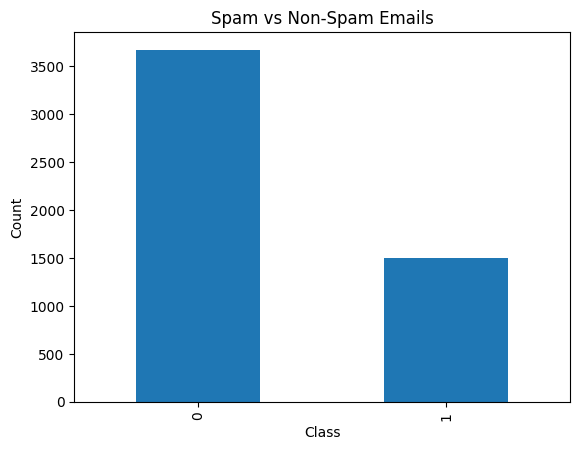

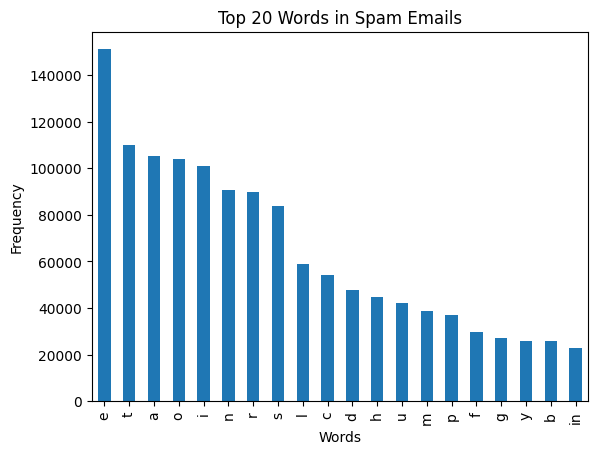

In [ ]:
#visualization
#1.Grouped Bars
df.columns = df.columns.str.strip()

# Spam vs Non-Spam
df['Prediction'].value_counts().plot(kind='bar')
plt.title("Spam vs Non-Spam Emails")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Top spam words
spam_words = (
    df[df['Prediction'] == 1]
    .select_dtypes(include='number')
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

spam_words.plot(kind='bar')
plt.title("Top 20 Words in Spam Emails")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


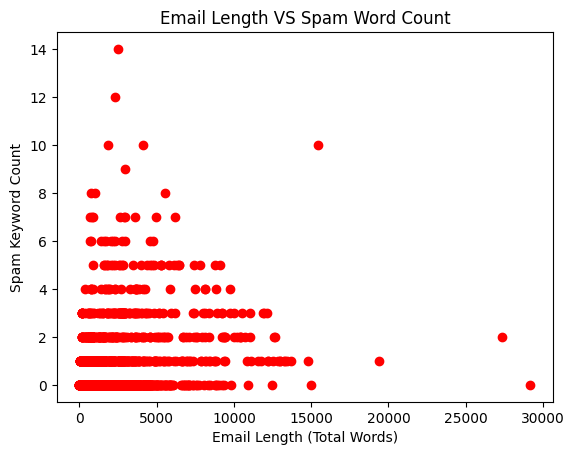

In [ ]:
#2. Scatter Plot
df['email_length'] = df.select_dtypes(include='number').sum(axis=1)
spam_keywords = ['free','win','offer','money']
existing = [w for w in spam_keywords if w in df.columns]
df['spam_word_count'] = df[existing].sum(axis=1)

plt.figure()
plt.scatter(df['email_length'],df['spam_word_count'],c='red')
plt.xlabel("Email Length (Total Words)")
plt.ylabel("Spam Keyword Count")
plt.title("Email Length VS Spam Word Count")
plt.show()

In [ ]:
#Data Preprocessing
#Checking for null values
df.isnull().sum()

#Drop unnecessary columns
df = df.drop(columns=['Email No.'])
print(df)

      the  to  ect  and  for  of    a  you  hou  in  ...  valued  lay  \
0       0   0    1    0    0   0    2    0    0   0  ...       0    0   
1       8  13   24    6    6   2  102    1   27  18  ...       0    0   
2       0   0    1    0    0   0    8    0    0   4  ...       0    0   
3       0   5   22    0    5   1   51    2   10   1  ...       0    0   
4       7   6   17    1    5   2   57    0    9   3  ...       0    0   
...   ...  ..  ...  ...  ...  ..  ...  ...  ...  ..  ...     ...  ...   
5167    2   2    2    3    0   0   32    0    0   5  ...       0    0   
5168   35  27   11    2    6   5  151    4    3  23  ...       0    0   
5169    0   0    1    1    0   0   11    0    0   1  ...       0    0   
5170    2   7    1    0    2   1   28    2    0   8  ...       0    0   
5171   22  24    5    1    6   5  148    8    2  23  ...       0    0   

      infrastructure  military  allowing  ff  dry  Prediction  email_length  \
0                  0         0         0   0

In [ ]:
#Separating features & target
X = df.drop("Prediction",axis=1)
y = df["Prediction"]

In [ ]:
#Normalize / Standardize Numerics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Feature Matrix Shape:",X_scaled.shape)


Scaled Feature Matrix Shape: (5172, 3002)


In [ ]:
#Feature Selection
chi2_selector = SelectKBest(score_func=chi2, k='all')  # k='all' computes score for every feature
X_chi2 = chi2_selector.fit_transform(X, y)

# Create a DataFrame with all scores
chi2_scores = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi2_selector.scores_
}).sort_values(by="Chi2 Score", ascending=False)

print("\nChi-Square Scores for All Features:")
print(chi2_scores)

#select features with score above mean
threshold = chi2_scores["Chi2 Score"].mean()
selected_features = chi2_scores[chi2_scores["Chi2 Score"] > threshold]["Feature"].tolist()
print("\nChi-Square Selected Features (above mean score):")
print(selected_features)


Chi-Square Scores for All Features:
           Feature     Chi2 Score
3000  email_length  156908.776572
14               i   20933.845216
23               s    9905.907062
173              r    9581.168541
6                a    8297.355495
...            ...            ...
2109        pretty       0.000056
2113         taxes       0.000056
2876      forecast       0.000056
478          field       0.000048
1830        launch       0.000027

[3002 rows x 2 columns]

Chi-Square Selected Features (above mean score):
['email_length', 'i', 's', 'r', 'a', 'o', 'n', 'e', 'p', 't', 'd', 'l', 'g', 'in', 'f', 'b', 'u', 'v', 'of', 'ect', 'enron', 'z', 're', 'ic', 'c', 'ur', 'st', 'y', 'it', 'ti', 'm', 'q', 'w', 'hou', 'x', 'font', 'ali', 'ii', 'nd', 'ct', 'our', 'http', 've', 'ce', 'an', 'sec', 'us', 'mo', 'hpl', 'td', 'pa', 'ad', 'la', 'soft', 'ma', 'eight', 'al', 'nbsp', 'invest', 'sp', 'ca', 'ut', 'statements', 'spam_word_count', 'com', 'at', 'le', 'co', 'is', 'oo', 'pro', 'or', 'meter', 'dr'

In [ ]:
anova_selector = SelectKBest(score_func=f_classif, k='all')  # k='all' computes F-score for every feature
X_anova = anova_selector.fit_transform(X_scaled, y)

# Create a DataFrame with all scores
anova_scores = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA F-Score": anova_selector.scores_
}).sort_values(by="ANOVA F-Score", ascending=False)

print("\nANOVA Scores for All Features:")
print(anova_scores)

# Select features with F-score above mean
threshold = anova_scores["ANOVA F-Score"].mean()
selected_features_anova = anova_scores[anova_scores["ANOVA F-Score"] > threshold]["Feature"].tolist()
print("\nANOVA Selected Features (above mean score):")
print(selected_features_anova)


ANOVA Scores for All Features:
              Feature  ANOVA F-Score
160            thanks     411.200989
3001  spam_word_count     401.542670
37                hpl     395.314561
418             hanks     393.885525
785             thank     382.244973
...               ...            ...
2109           pretty       0.000044
2876         forecast       0.000035
2113            taxes       0.000034
478             field       0.000026
1830           launch       0.000009

[3002 rows x 2 columns]

ANOVA Selected Features (above mean score):
['thanks', 'spam_word_count', 'hpl', 'hanks', 'thank', 'more', 'attached', 'daren', 'forwarded', 'our', 'subject', 'hp', 'able', 'best', 'ur', 'sex', 'sec', 'money', 'soft', 'dr', 'mo', 'aren', 'via', 'prescription', 'remove', 'nom', 'cheap', 'meds', 'drug', 'of', 'ali', 'ic', 'farmer', 'questions', 'cia', 'deal', 'offer', 'off', 'than', 'volume', 'enron', 'your', 'prices', 'question', 'x', 'ii', 'paliourg', 'press', 'z', 'most', 'doctor', 'thousand'

In [ ]:
#Data Splitting
from sklearn.model_selection import train_test_split
#Split it into training and test
X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

#Validation and Test
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Training set:",X_train.shape,y_train.shape)
print("Validation set:",X_val.shape,y_val.shape)
print("Testing set:",X_test.shape,y_test.shape)

Training set: (3620, 3002) (3620,)
Validation set: (776, 3002) (776,)
Testing set: (776, 3002) (776,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score

# Train a new model for the current task
model = LogisticRegression(max_iter=200) # Increased max_iter for convergence if needed
model.fit(X_train, y_train)

# Make predictions using the X_test from the current task
y_pred = model.predict(X_test)

# Calculate F-beta score with the correct y_pred and y_test
fbeta = fbeta_score(y_test, y_pred, beta=0.5)
print("F-beta Score:", fbeta)

F-beta Score: 0.9229466553767993


**Justification**:

F-beta score (β < 1) is the most practical metric because false positives are more costly than false negatives, and F-beta emphasizes precision over recall.

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average = "macro")
print("F1 Score (Macro):",f1) #macro is used since each class should be treated equally

F1 Score (Macro): 0.956959939148073


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[530  21]
 [  7 218]]


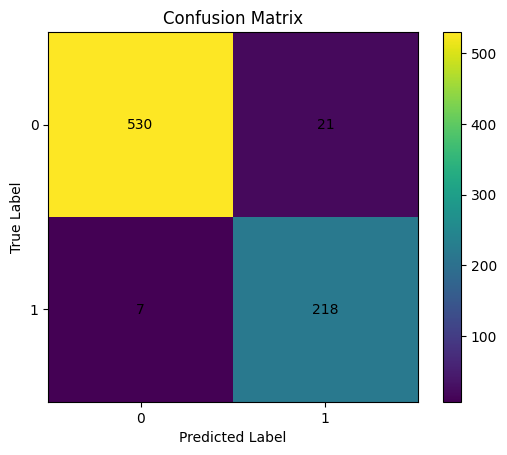

In [ ]:
#visualization
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

classes = np.unique(y_test)
plt.xticks(range(len(classes)),classes)
plt.yticks(range(len(classes)),classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha = "center",va="center")

plt.show()



**4. Diabetes Prediction**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

#Loading data set
df = pd.read_csv(r"/content/drive/MyDrive/diabetes_prediction_dataset.csv")
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [ ]:
#Exploratory data analysis

#summary statistics
print("\nInfo\n")
print(df.info())
print("\nColumns\n")
print(df.columns)
print("\nShape\n")
print(df.shape)
print("\nDescription\n")
print(df.describe())


Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None

Columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Shape

(100000, 9)

Description

                 age  hypertension  heart_disease

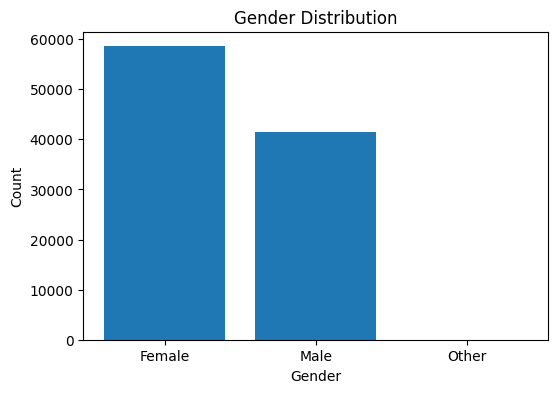

In [ ]:
#visualisation

#1.bar chart
plt.figure(figsize=(6,4))
gender_counts = df['gender'].value_counts()
plt.bar(gender_counts.index,gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

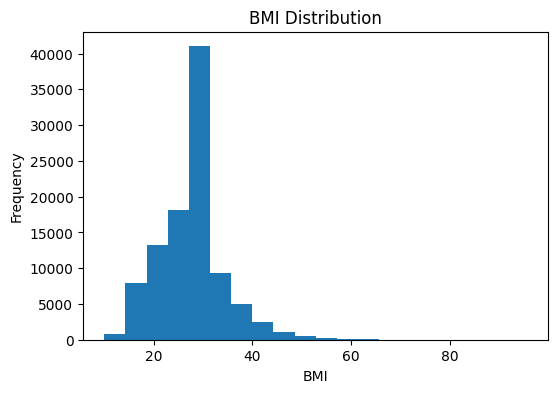

In [ ]:
#2.BMI
plt.figure(figsize=(6,4))
plt.hist(df['bmi'],bins = 20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

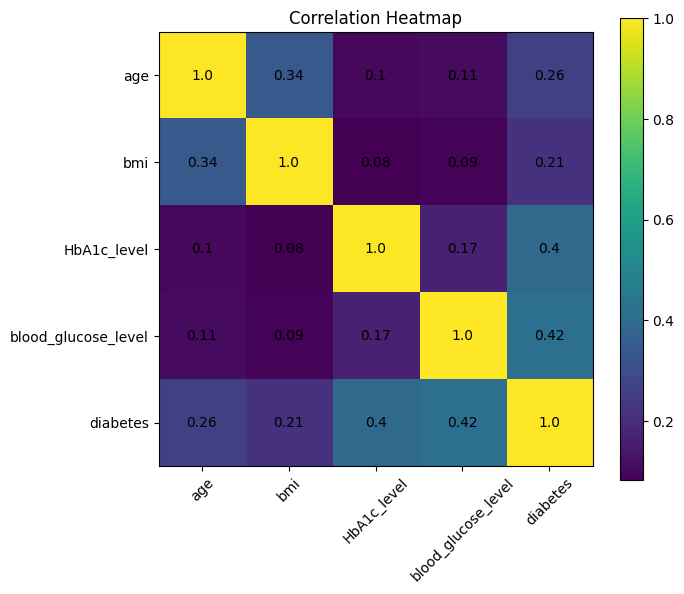

In [ ]:
#Heat Map


# Select numerical columns
numeric_df = df[['age','bmi','HbA1c_level','blood_glucose_level','diabetes']]

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(7,6))
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha="center", va="center")

plt.show()


In [ ]:
#Data preprocessing

#Checking for missing values
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
#Irrelevant features None
#Encode categorical variables
df["diabetes"] = df["diabetes"].astype("category").cat.codes
#Separate features and target
x = df.drop("diabetes",axis = 1)
y = df["diabetes"]

In [ ]:
#Normalize/Standardize data

x = pd.get_dummies(x,drop_first = True) #to convert text -> no's
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled,columns = x.columns)
print(X_scaled)

            age  hypertension  heart_disease       bmi  HbA1c_level  \
0      1.692704     -0.284439       4.936379 -0.321056     1.001706   
1      0.538006     -0.284439      -0.202578 -0.000116     1.001706   
2     -0.616691     -0.284439      -0.202578 -0.000116     0.161108   
3     -0.261399     -0.284439      -0.202578 -0.583232    -0.492690   
4      1.515058      3.515687       4.936379 -1.081970    -0.679490   
...         ...           ...            ...       ...          ...   
99995  1.692704     -0.284439      -0.202578 -0.000116     0.628107   
99996 -1.771388     -0.284439      -0.202578 -1.499343     0.908306   
99997  1.070944     -0.284439      -0.202578  0.076729     0.161108   
99998 -0.794336     -0.284439      -0.202578  1.220361    -1.426688   
99999  0.671241     -0.284439      -0.202578 -0.736922     1.001706   

       blood_glucose_level  gender_Male  gender_Other  \
0                 0.047704    -0.841046     -0.013418   
1                -1.426210    -0.

In [ ]:
#Feature Selection
from sklearn.feature_selection import SelectKBest,chi2

#selectKBest with chi2
chi2_selector = SelectKBest(score_func = chi2,k=2)
X_chi2 = chi2_selector.fit_transform(x,y) #use x since X_scaled may contain -ve's
print("Chi-square Selected Features Shape:",X_chi2)

Chi-square Selected Features Shape: [[ 80. 140.]
 [ 54.  80.]
 [ 28. 158.]
 ...
 [ 66. 155.]
 [ 24. 100.]
 [ 57.  90.]]


In [ ]:
chi2_scores = pd.DataFrame({
    "Feature":x.columns,
    "Chi2 Score":chi2_selector.scores_
})
print(chi2_scores.sort_values(by="Chi2 Score",ascending=False))

                        Feature     Chi2 Score
5           blood_glucose_level  211290.674736
0                           age   80576.722304
3                           bmi    7407.898843
1                  hypertension    3620.485416
4                   HbA1c_level    3329.139367
2                 heart_disease    2832.761069
10       smoking_history_former     869.114789
6                   gender_Male      83.096327
9          smoking_history_ever      55.663898
11        smoking_history_never      48.255687
12  smoking_history_not current      40.216992
8       smoking_history_current      34.868272
7                  gender_Other       1.672131


In [ ]:
from sklearn.feature_selection import f_classif
anova_selector = SelectKBest(score_func = f_classif,k=2)
X_annova = anova_selector.fit_transform(X_scaled,y)
print("ANOVA Selected Features Shape:",X_annova.shape)

ANOVA Selected Features Shape: (100000, 2)


In [ ]:
anova_scores = pd.DataFrame({
    "Feature":x.columns,
    "ANOVA F-Score":anova_selector.scores_
})
print(anova_scores.sort_values(by="ANOVA F-Score",ascending=False))

                        Feature  ANOVA F-Score
5           blood_glucose_level   21363.054361
4                   HbA1c_level   19122.211184
0                           age    7131.405852
3                           bmi    4816.113932
1                  hypertension    4072.706875
2                 heart_disease    3038.559564
10       smoking_history_former     968.042101
6                   gender_Male     142.073969
11        smoking_history_never      74.402011
9          smoking_history_ever      58.018125
12  smoking_history_not current      43.006086
8       smoking_history_current      38.451597
7                  gender_Other       1.672427


In [ ]:
selected_features = x.columns[anova_selector.get_support()]
print("Selected Features:",list(selected_features))

Selected Features: ['HbA1c_level', 'blood_glucose_level']


In [ ]:
#Data Splitting
from sklearn.model_selection import train_test_split
#Split it into training and test
X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

#Validation and Test
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Training set:",X_train.shape,y_train.shape)
print("Validation set:",X_val.shape,y_val.shape)
print("Testing set:",X_test.shape,y_test.shape)


Training set: (70000, 13) (70000,)
Validation set: (15000, 13) (15000,)
Testing set: (15000, 13) (15000,)


In [ ]:
#Performance Evaluation

#Accuracy -> since dataset is balanced
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

model = LogisticRegression(max_iter = 200)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy is:",accuracy)

Accuracy is: 0.9598666666666666


In [ ]:
#F1-Score
f1 = f1_score(y_test,y_pred,average = "macro")
print("F1 Score (Macro):",f1) #macro is used since each class should be treated equally

F1 Score (Macro): 0.8526012307976784


In [ ]:
#Recall score
from sklearn.metrics import recall_score
recall = recall_score(y_test,y_pred,pos_label = 1)
print("Recall:",recall)

Recall: 0.6282352941176471


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[13597   128]
 [  474   801]]


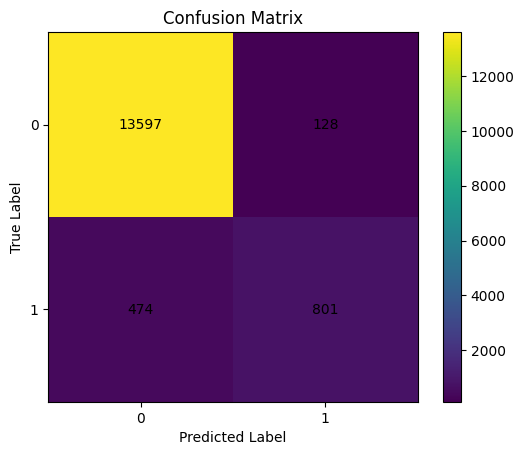

In [ ]:
#visualization
#visualization

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

classes = np.unique(y_test)
plt.xticks(range(len(classes)),classes)
plt.yticks(range(len(classes)),classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha = "center",va="center")

plt.show()


**5. IRIS DATASET**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


#Loading data set
df = pd.read_csv(r"/content/drive/MyDrive/iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
#Exploratory data analysis

#summary statistics
print("\nInfo\n")
print(df.info())
print("\nColumns\n")
print(df.columns)
print("\nShape\n")
print(df.shape)
print("\nDescription\n")
print(df.describe())


Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Shape

(150, 5)

Description

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000 

Text(0, 0.5, 'Count')

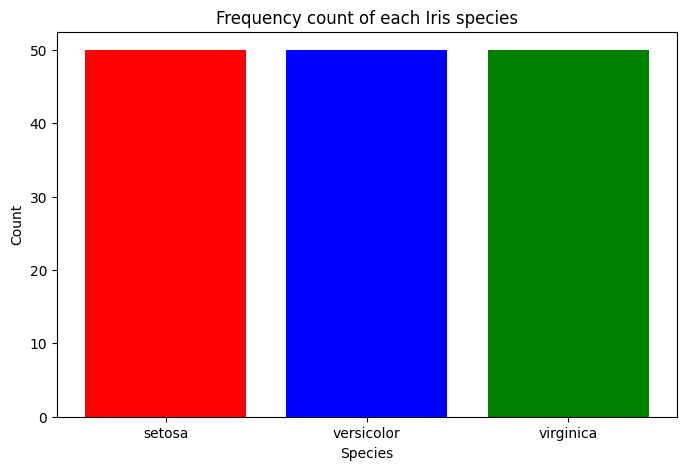

In [ ]:
#visualisation

#1.bar chart
species_counts = df['species'].value_counts()
categories = species_counts.index
counts = species_counts.values

plt.figure(figsize=(8,5))
plt.bar(categories,counts,color = ['red','blue','green'])
plt.title("Frequency count of each Iris species")
plt.xlabel("Species")
plt.ylabel("Count")


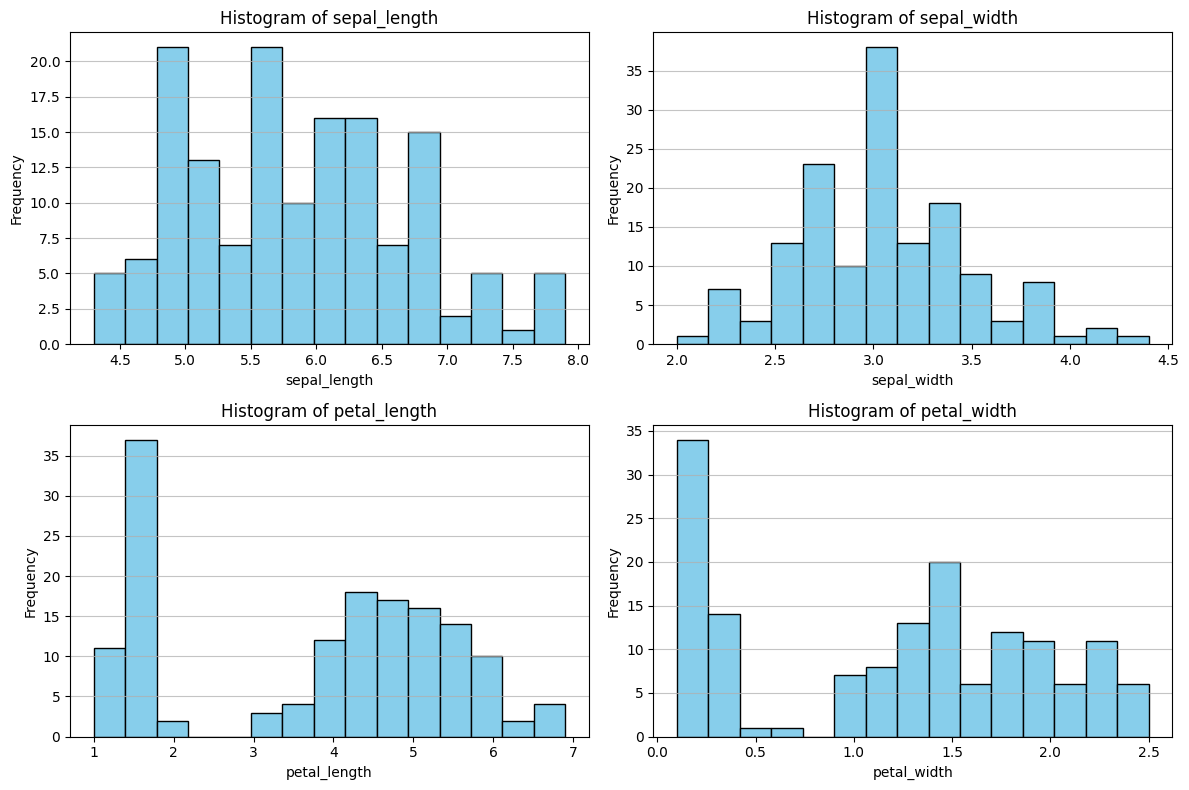

In [ ]:
#2.Histograms
fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(12,8))
axes_flat = axes.flatten()
features = ['sepal_length','sepal_width','petal_length','petal_width']
for i,feature in enumerate(features):
    ax = axes_flat[i]
    ax.hist(df[feature],bins = 15,color='skyblue',edgecolor='black')
    ax.set_title(f'Histogram of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(axis = 'y',alpha = 0.75)
#prevent overlap
plt.tight_layout()
plt.show()

In [ ]:
#Data preprocessing

#Checking for missing values
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
#Irrelevant features None
#Encode categorical variables
df["species"] = df["species"].astype("category").cat.codes


#Separate features and target
x = df.drop("species",axis = 1)
y = df["species"]
df
print(x)
print(y)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int8


In [ ]:
#Normalize/Standardize data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
print(X_scaled)

[[-9.00681170e-01  1.03205722e+00 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00 -1.24957601e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.38535265e+00  3.37848329e-01 -1.39813811e+00 -1.31297673e+00]
 [-1.50652052e+00  1.06445364e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.02184904e+00  1.26346019e+00 -1.34127240e+00 -1.31297673e+00]
 [-5.37177559e-01  1.95766909e+00 -1.17067529e+00 -1.05003079e+00]
 [-1.50652052e+00  8.00654259e-01 -1.34127240e+00 -1.18150376e+00]
 [-1.02184904e+00  8.00654259e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.74885626e+00 -3.56360566e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00  1.06445364e-01 -1.28440670e+00 -1.44444970e+00]
 [-5.37177559e-01  1.49486315e+00 -1.28440670e+00 -1.31297673e+00]
 [-1.26418478e+00  8.00654259e-01 -1.22754100e+00 -1.31297673e+00]
 [-1.26418478e+00 -1.24957601e-01 -1.34127240e+00 -1.44444970e+00]
 [-1.87002413e+00 -1.24957601e-01 -1.51186952e+00 -1.44444970e+00]
 [-5.25060772e-02  2.18907205e+00 -1.45500381e+00 -1.31297673e

In [ ]:
#Feature Selection
from sklearn.feature_selection import SelectKBest,chi2

#selectKBest with chi2
chi2_selector = SelectKBest(score_func = chi2,k=2)
X_chi2 = chi2_selector.fit_transform(x,y) #use x since X_scaled may contain -ve's
print("Chi-square Selected Features Shape:",X_chi2)

Chi-square Selected Features Shape: [[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.1]
 [1.2 0.2]
 [1.3 0.2]
 [1.5 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1

In [ ]:
chi2_scores = pd.DataFrame({
    "Feature":x.columns,
    "Chi2 Score":chi2_selector.scores_
})
print(chi2_scores.sort_values(by="Chi2 Score",ascending=False))

        Feature  Chi2 Score
2  petal_length  116.169847
3   petal_width   67.244828
0  sepal_length   10.817821
1   sepal_width    3.594499


In [ ]:
from sklearn.feature_selection import f_classif
anova_selector = SelectKBest(score_func = f_classif,k=2)
X_annova = anova_selector.fit_transform(X_scaled,y)
print("ANOVA Selected Features Shape:",X_annova.shape)

ANOVA Selected Features Shape: (150, 2)


In [ ]:
anova_scores = pd.DataFrame({
    "Feature":x.columns,
    "ANOVA F-Score":anova_selector.scores_
})
print(anova_scores.sort_values(by="ANOVA F-Score",ascending=False))

        Feature  ANOVA F-Score
2  petal_length    1179.034328
3   petal_width     959.324406
0  sepal_length     119.264502
1   sepal_width      47.364461


In [ ]:
selected_features = x.columns[anova_selector.get_support()]
print("Selected Features:",list(selected_features))

Selected Features: ['petal_length', 'petal_width']


In [ ]:
#Data Splitting
from sklearn.model_selection import train_test_split
#Split it into training and test
X_train,X_temp,y_train,y_temp = train_test_split(
    X_scaled,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

#Validation and Test
X_val,X_test,y_val,y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Training set:",X_train.shape,y_train.shape)
print("Validation set:",X_val.shape,y_val.shape)
print("Testing set:",X_test.shape,y_test.shape)


Training set: (105, 4) (105,)
Validation set: (22, 4) (22,)
Testing set: (23, 4) (23,)


In [ ]:
#Performance Evaluation

#Accuracy -> since dataset is balanced
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

model = LogisticRegression(max_iter = 200)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy is:",accuracy)

Accuracy is: 0.9565217391304348


In [ ]:
#F1-Score
f1 = f1_score(y_test,y_pred,average = "macro")
print("F1 Score (Macro):",f1) #macro is used since each class should be treated equally

F1 Score (Macro): 0.9581699346405229


In [ ]:
#confusion matrix
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[7 0 0]
 [0 8 0]
 [0 1 7]]


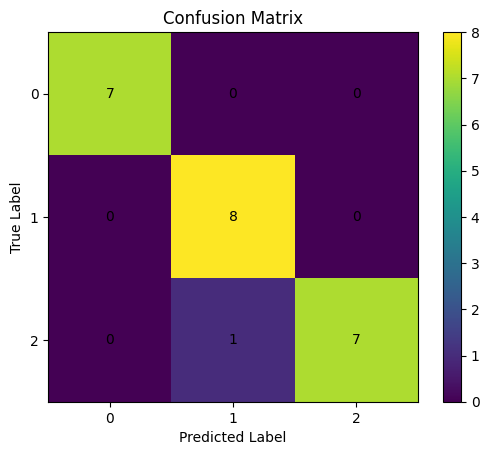

In [ ]:
#visualization

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

classes = np.unique(y_test)
plt.xticks(range(len(classes)),classes)
plt.yticks(range(len(classes)),classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha = "center",va="center")

plt.show()